# Seoul Bike Data Final Report
Amelia Jiang-Yu: ajiangy1@jhu.edu  
Raj Gosain: rgosain3@jhu.edu

## 0 Introduction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### a. Data Set

Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

The Seoul Bike Sharing Demand dataset details the number of public bicycles rented each hour via the Seoul Bike Sharing System. The dataset includes weather information such Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, and Rainfall. Other information includes the season, whether the day is a holiday or not, and whether the hour is functional or not.

The response variable is **rented bike count** at each hour. Explanatory variables include:
- **Date**: categorical
- **Hour**: categorical
- **Temperature** (in Celsius): continuous
- **Humidity** (%): continuous
- **Wind Speed** (m/s): continuous
- **Visibility** (10 m): integer-valued
- **Dew Point Temperature** (in Celsius): continuous
- **Solar Radiation** (MJ/m2): continuous
- **Rainfall** (mm): continuous
- **Snowfall** (cm): continuous
- **Seasons**: categorical (winter, spring, summer, fall)
- **Holiday**: binary (holiday, no holiday)
- **Functioning Day**: binary (yes, no)

In [3]:
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")
df['Hour'] = df['Hour'].astype('category')


print(df.shape)
df.head()

(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### b. Data Visualization

In [4]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = ['Date', 'Hour', 'Seasons']
binary_cols = ['Holiday', 'Functioning Day']

print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)
print("Binary:", binary_cols)

Categorical: ['Date', 'Hour', 'Seasons']
Continuous: ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
Binary: ['Holiday', 'Functioning Day']


#### Categorical Variables
The categorical variables are:
- Date
- Hour
- Season

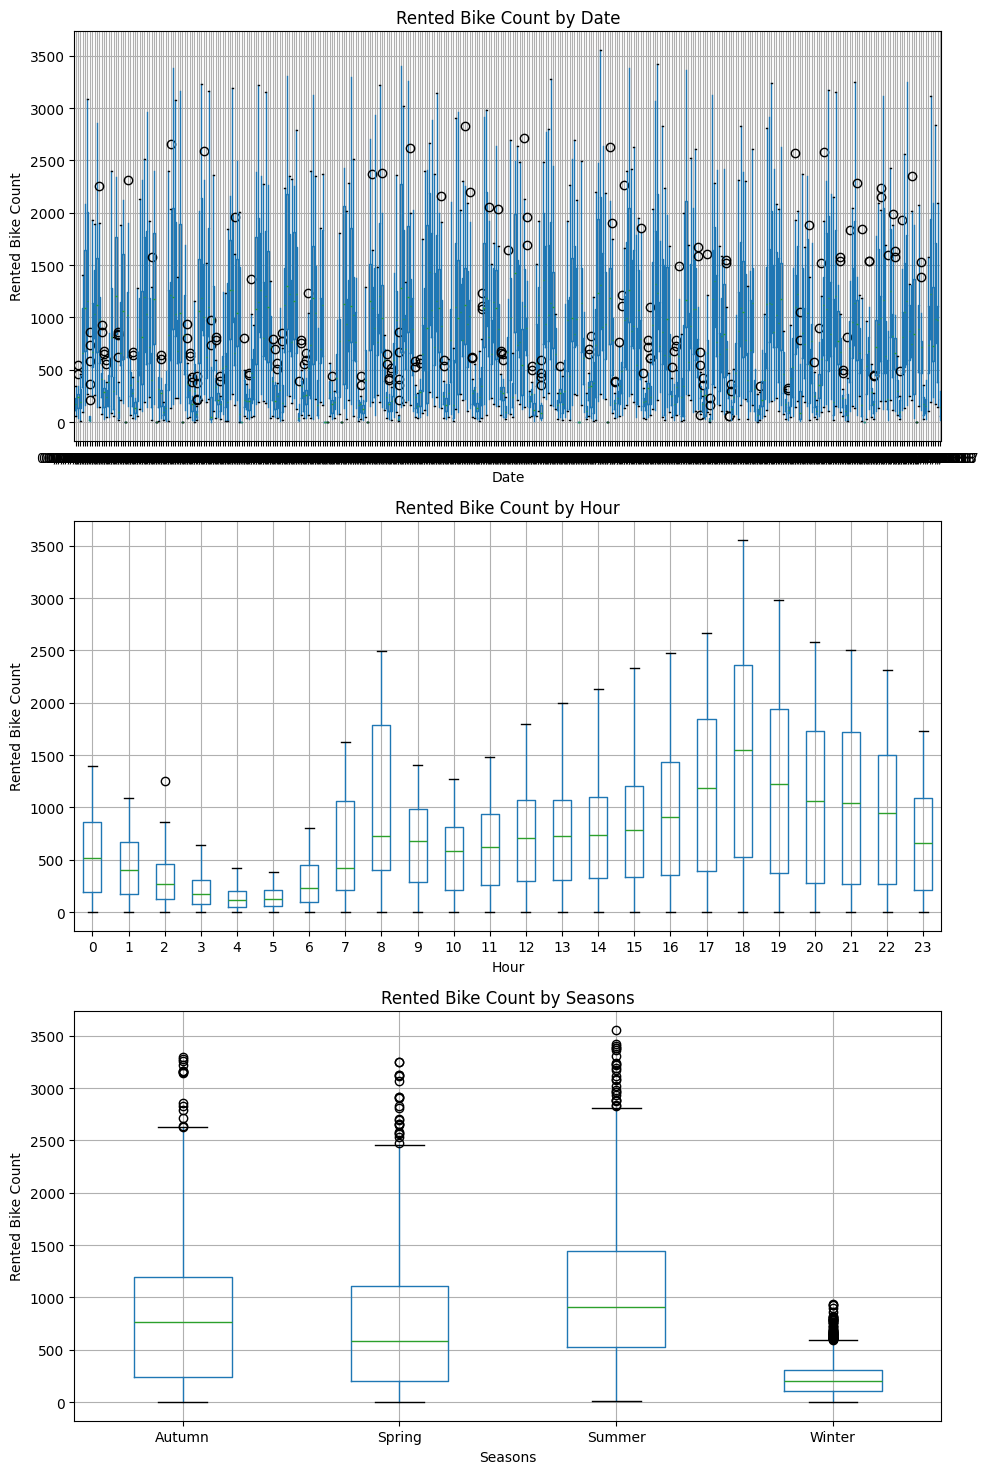

In [5]:
Y = 'Rented Bike Count'


fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs = axs.flatten()

i = 0
for col in categorical_cols:
    if col != Y:
        df.boxplot(column=Y, by=col, ax=axs[i])

        axs[i].set_title(f'{Y} by {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)

        i += 1

# Remove the automatic "Boxplot grouped by ..." super-title
plt.suptitle("")

plt.tight_layout()
plt.show()


There is a spike in **Rented Bike Count** at the hours of 8 (8 am) and 18 (6 pm), which is consistent with when people generally go to work in the morning and return home in the evening. As expected, **Rented Bike Count** is higher in Autumn, Spring, and Summer compared to Winter.

#### Continuous Variables

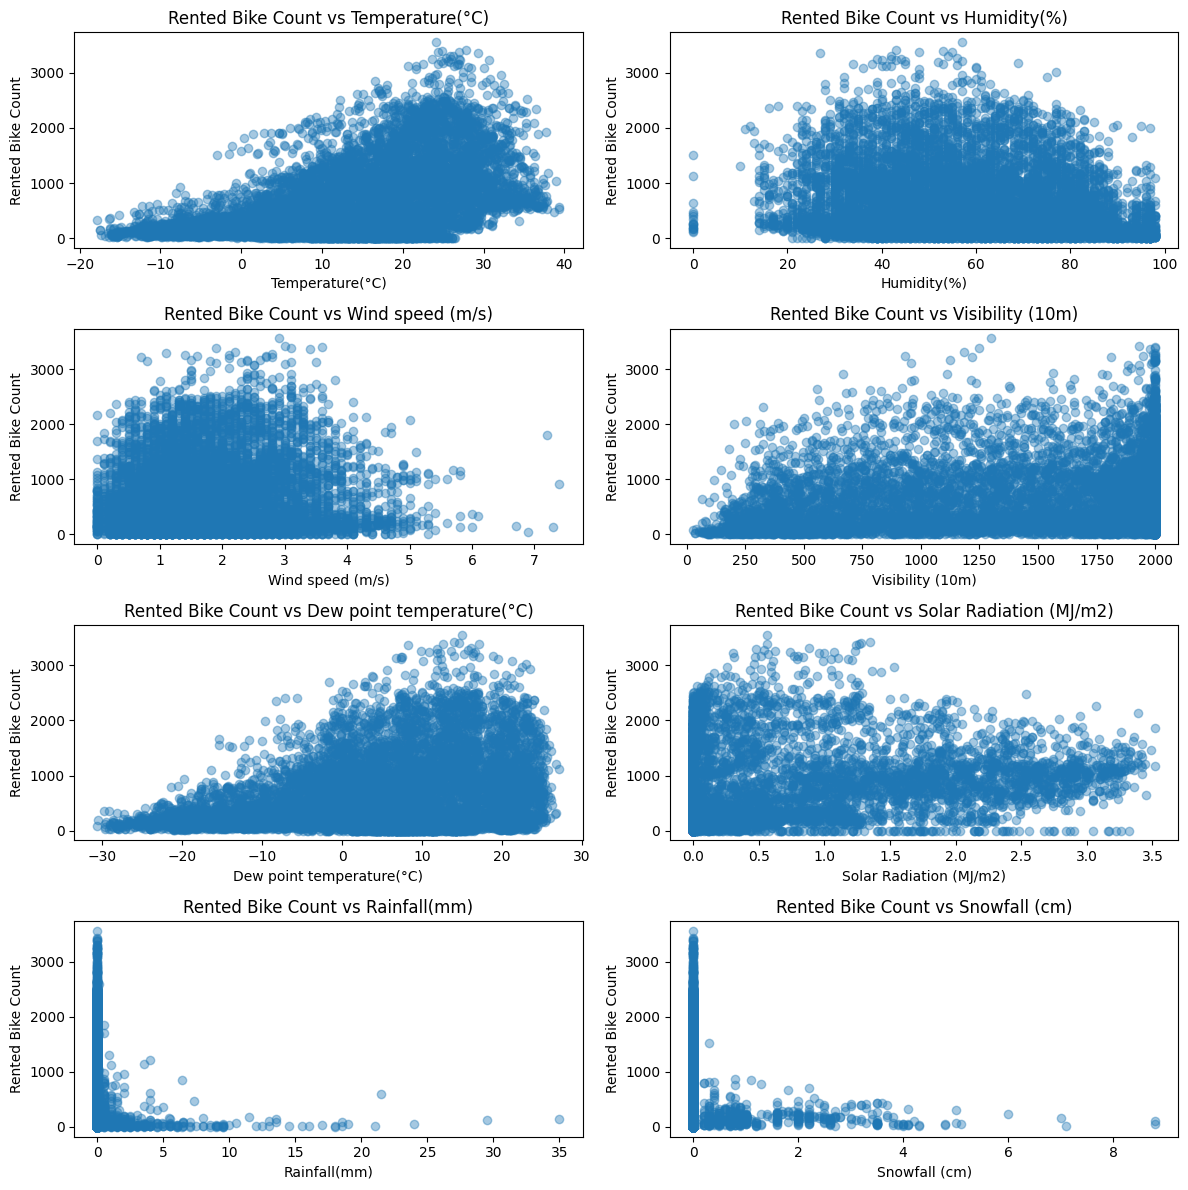

In [6]:
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
axs = axs.flatten()   # flatten to make indexing easier

i = 0
for col in continuous_cols:
    if col != Y:
        ax = axs[i]
        ax.scatter(df[col], df[Y], alpha=0.4)
        ax.set_xlabel(col)
        ax.set_ylabel(Y)
        ax.set_title(f'{Y} vs {col}')
        i += 1

plt.tight_layout()
plt.show()


#### Binary Variables

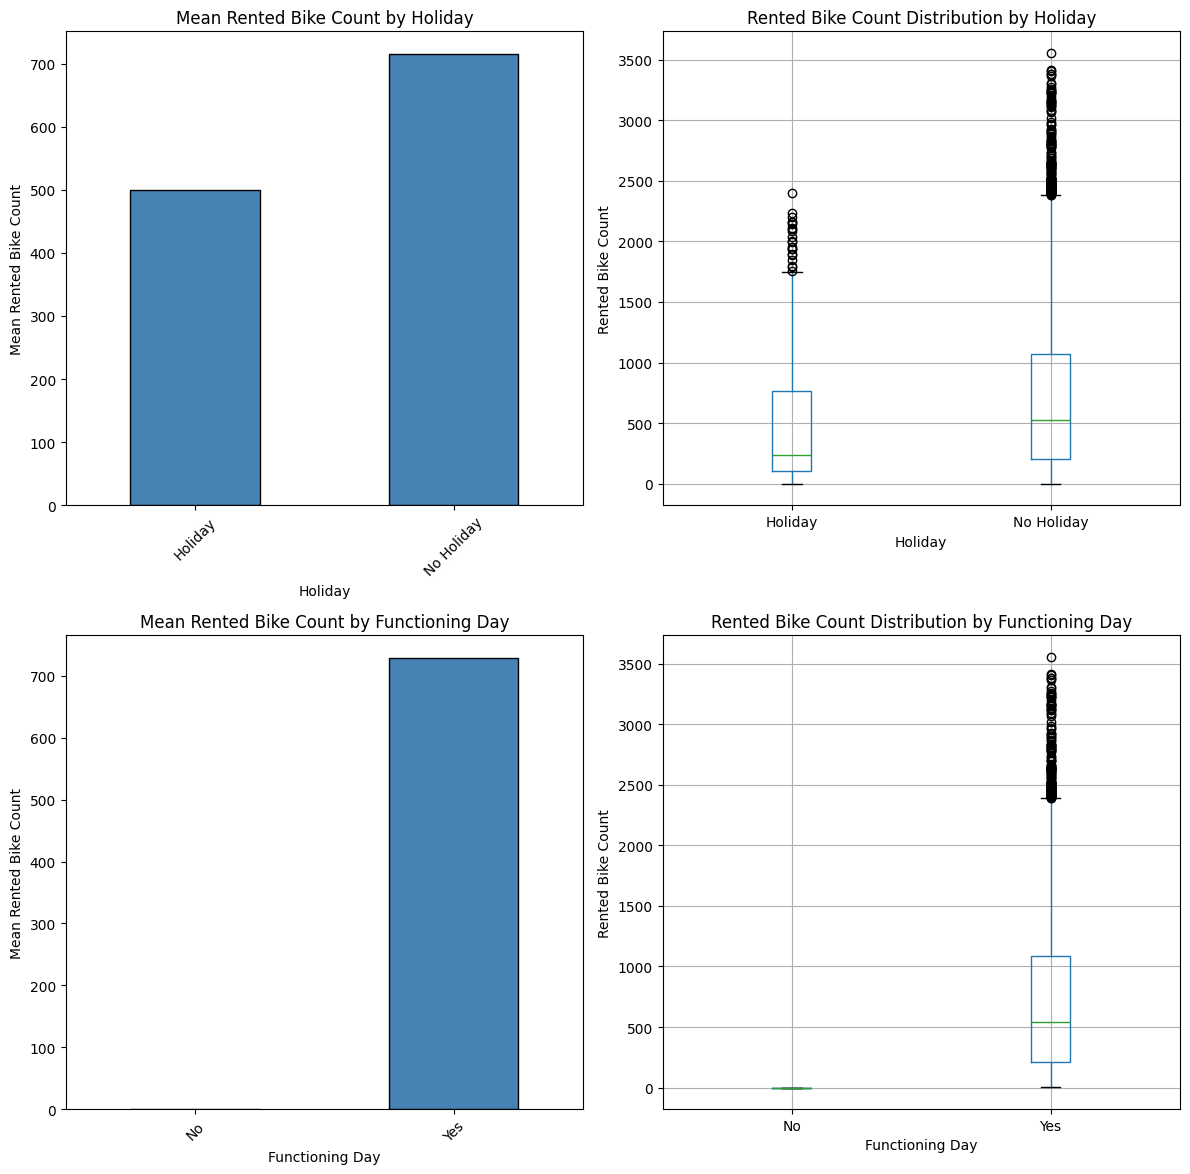

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

i = 0
for col in binary_cols:
    if col != Y:

        # --- Proportion bar plot ---
        prop = df.groupby(col)[Y].mean()
        ax = axs[i]

        prop.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
        ax.set_title(f'Mean {Y} by {col}')
        ax.set_ylabel(f'Mean {Y}')
        ax.set_xlabel(col)
        ax.set_xticks(range(len(prop.index)))
        ax.set_xticklabels(prop.index.astype(str), rotation=45)

        i += 1

        # --- Boxplot ---
        ax = axs[i]
        df.boxplot(column=Y, by=col, ax=ax)

        ax.set_title(f'{Y} Distribution by {col}')
        ax.set_xlabel(col)
        ax.set_ylabel(Y)

        # Remove the automatic "Boxplot grouped by col" super-title
        plt.suptitle("")

        i += 1

plt.tight_layout()
plt.show()



**Rented Bike Count** is generally higher on non-holiday days compared to holiday days. We can also see that **Rented Bike Count** is always zero (0) on non-functioning days.

### c. Descriptive Statistics

#### Categorical Variables

In [8]:
print(df[categorical_cols].describe(include='all'))

              Date  Hour Seasons
count         8760  8760    8760
unique         365    24       4
top     01/12/2017     0  Spring
freq            24   365    2208


With 365 unique dates, we can see that the data set extends for an exactly 1 year. Each date has 24 instances, one for each hour. Each hour has 365 instances, one for each date.

#### Continuous Variables

In [9]:
print(df[continuous_cols].describe(include='all'))

       Rented Bike Count  Temperature(°C)  Humidity(%)  Wind speed (m/s)  \
count        8760.000000      8760.000000  8760.000000       8760.000000   
mean          704.602055        12.882922    58.226256          1.724909   
std           644.997468        11.944825    20.362413          1.036300   
min             0.000000       -17.800000     0.000000          0.000000   
25%           191.000000         3.500000    42.000000          0.900000   
50%           504.500000        13.700000    57.000000          1.500000   
75%          1065.250000        22.500000    74.000000          2.300000   
max          3556.000000        39.400000    98.000000          7.400000   

       Visibility (10m)  Dew point temperature(°C)  Solar Radiation (MJ/m2)  \
count       8760.000000                8760.000000              8760.000000   
mean        1436.825799                   4.073813                 0.569111   
std          608.298712                  13.060369                 0.868746   

Mean **Rented Bike Count** is 704.6. The minumum is 0 and the maximum is 3556.

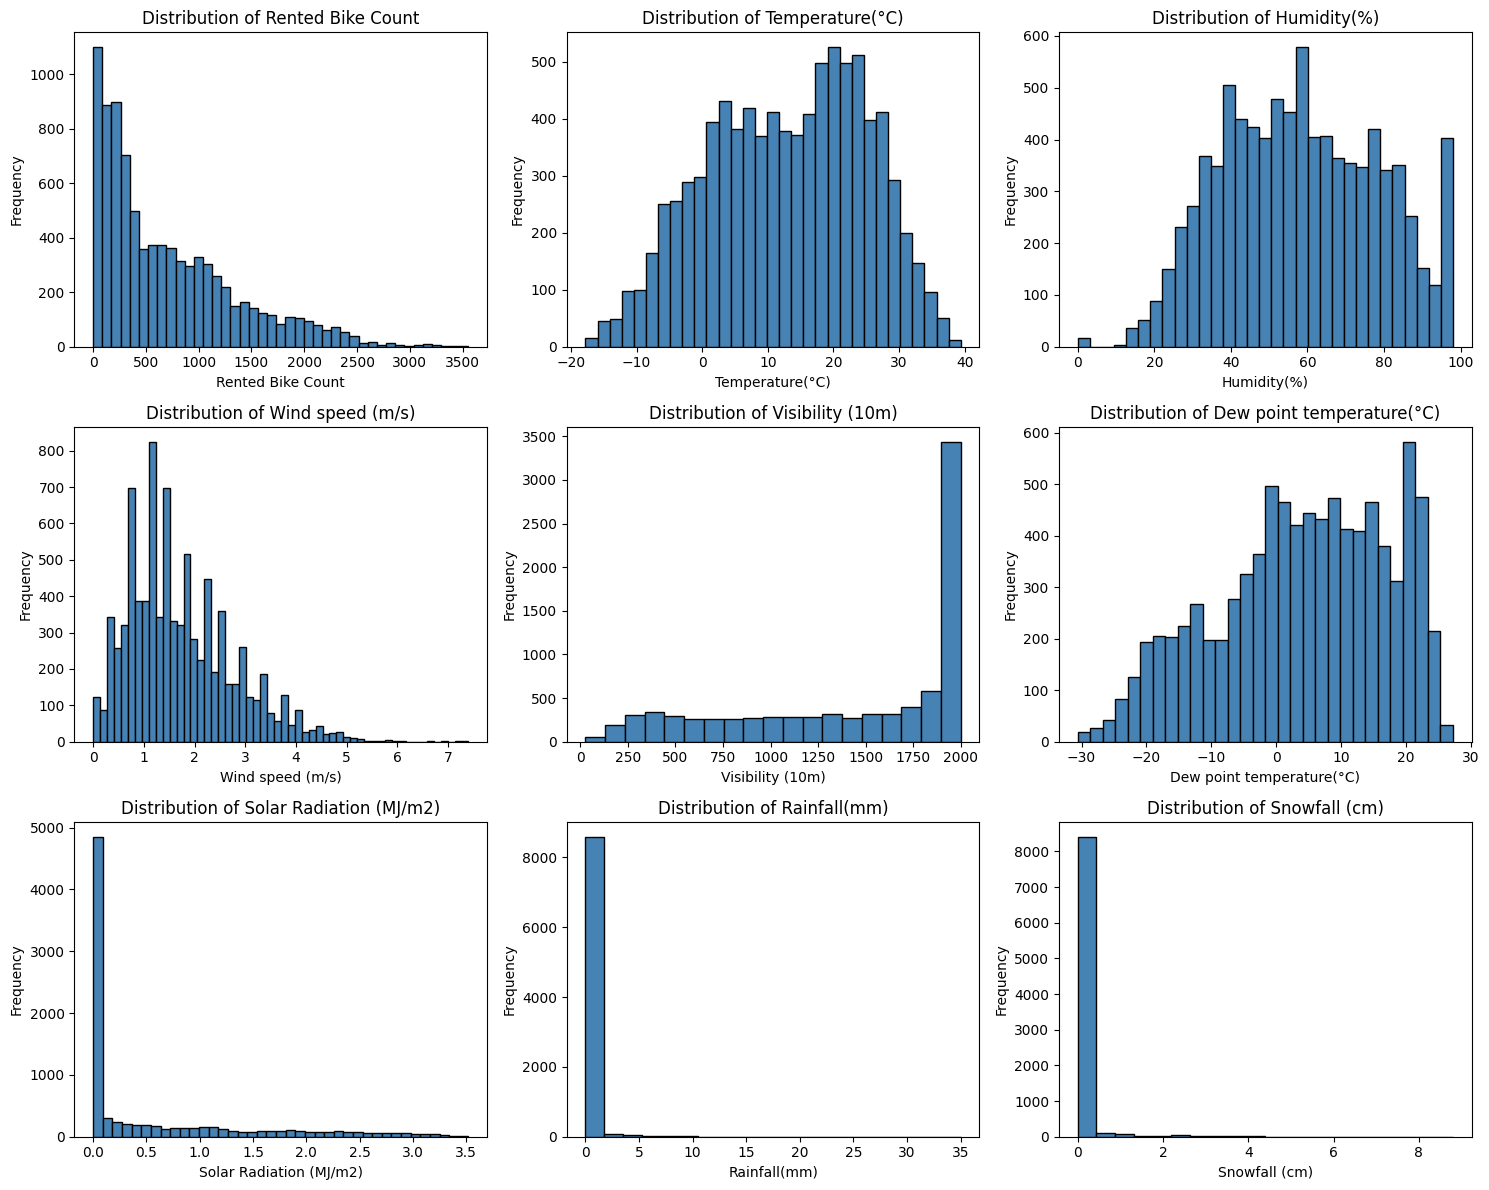

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs = axs.flatten()

for i, col in enumerate(continuous_cols):

    # Freedman–Diaconis rule for optimal bin width
    q75, q25 = np.percentile(df[col].dropna(), [75 ,25])
    iqr = q75 - q25
    n = df[col].dropna().shape[0]

    bin_width = 2 * iqr / (n ** (1/3)) if iqr > 0 else None
    if bin_width and bin_width > 0:
        bins = int((df[col].max() - df[col].min()) / bin_width)
    else:
        bins = 20  # fallback if IQR = 0 or data is constant

    axs[i].hist(df[col], bins=bins, edgecolor='black', color='steelblue')
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Rented Bike Count** is right-skewed, with inflated zeroes (0s). **Temperature** and **humidity** follow a relatively normal distribution. **Wind speed** is right-skewed. **Visibility** spikes at 2000 m. **Dew point temperature** is left-skewed. **Solar radiation**, **rainfall**, and **frequency** all spike at 0 (MJ/m2, mm, and cmm, respectively).

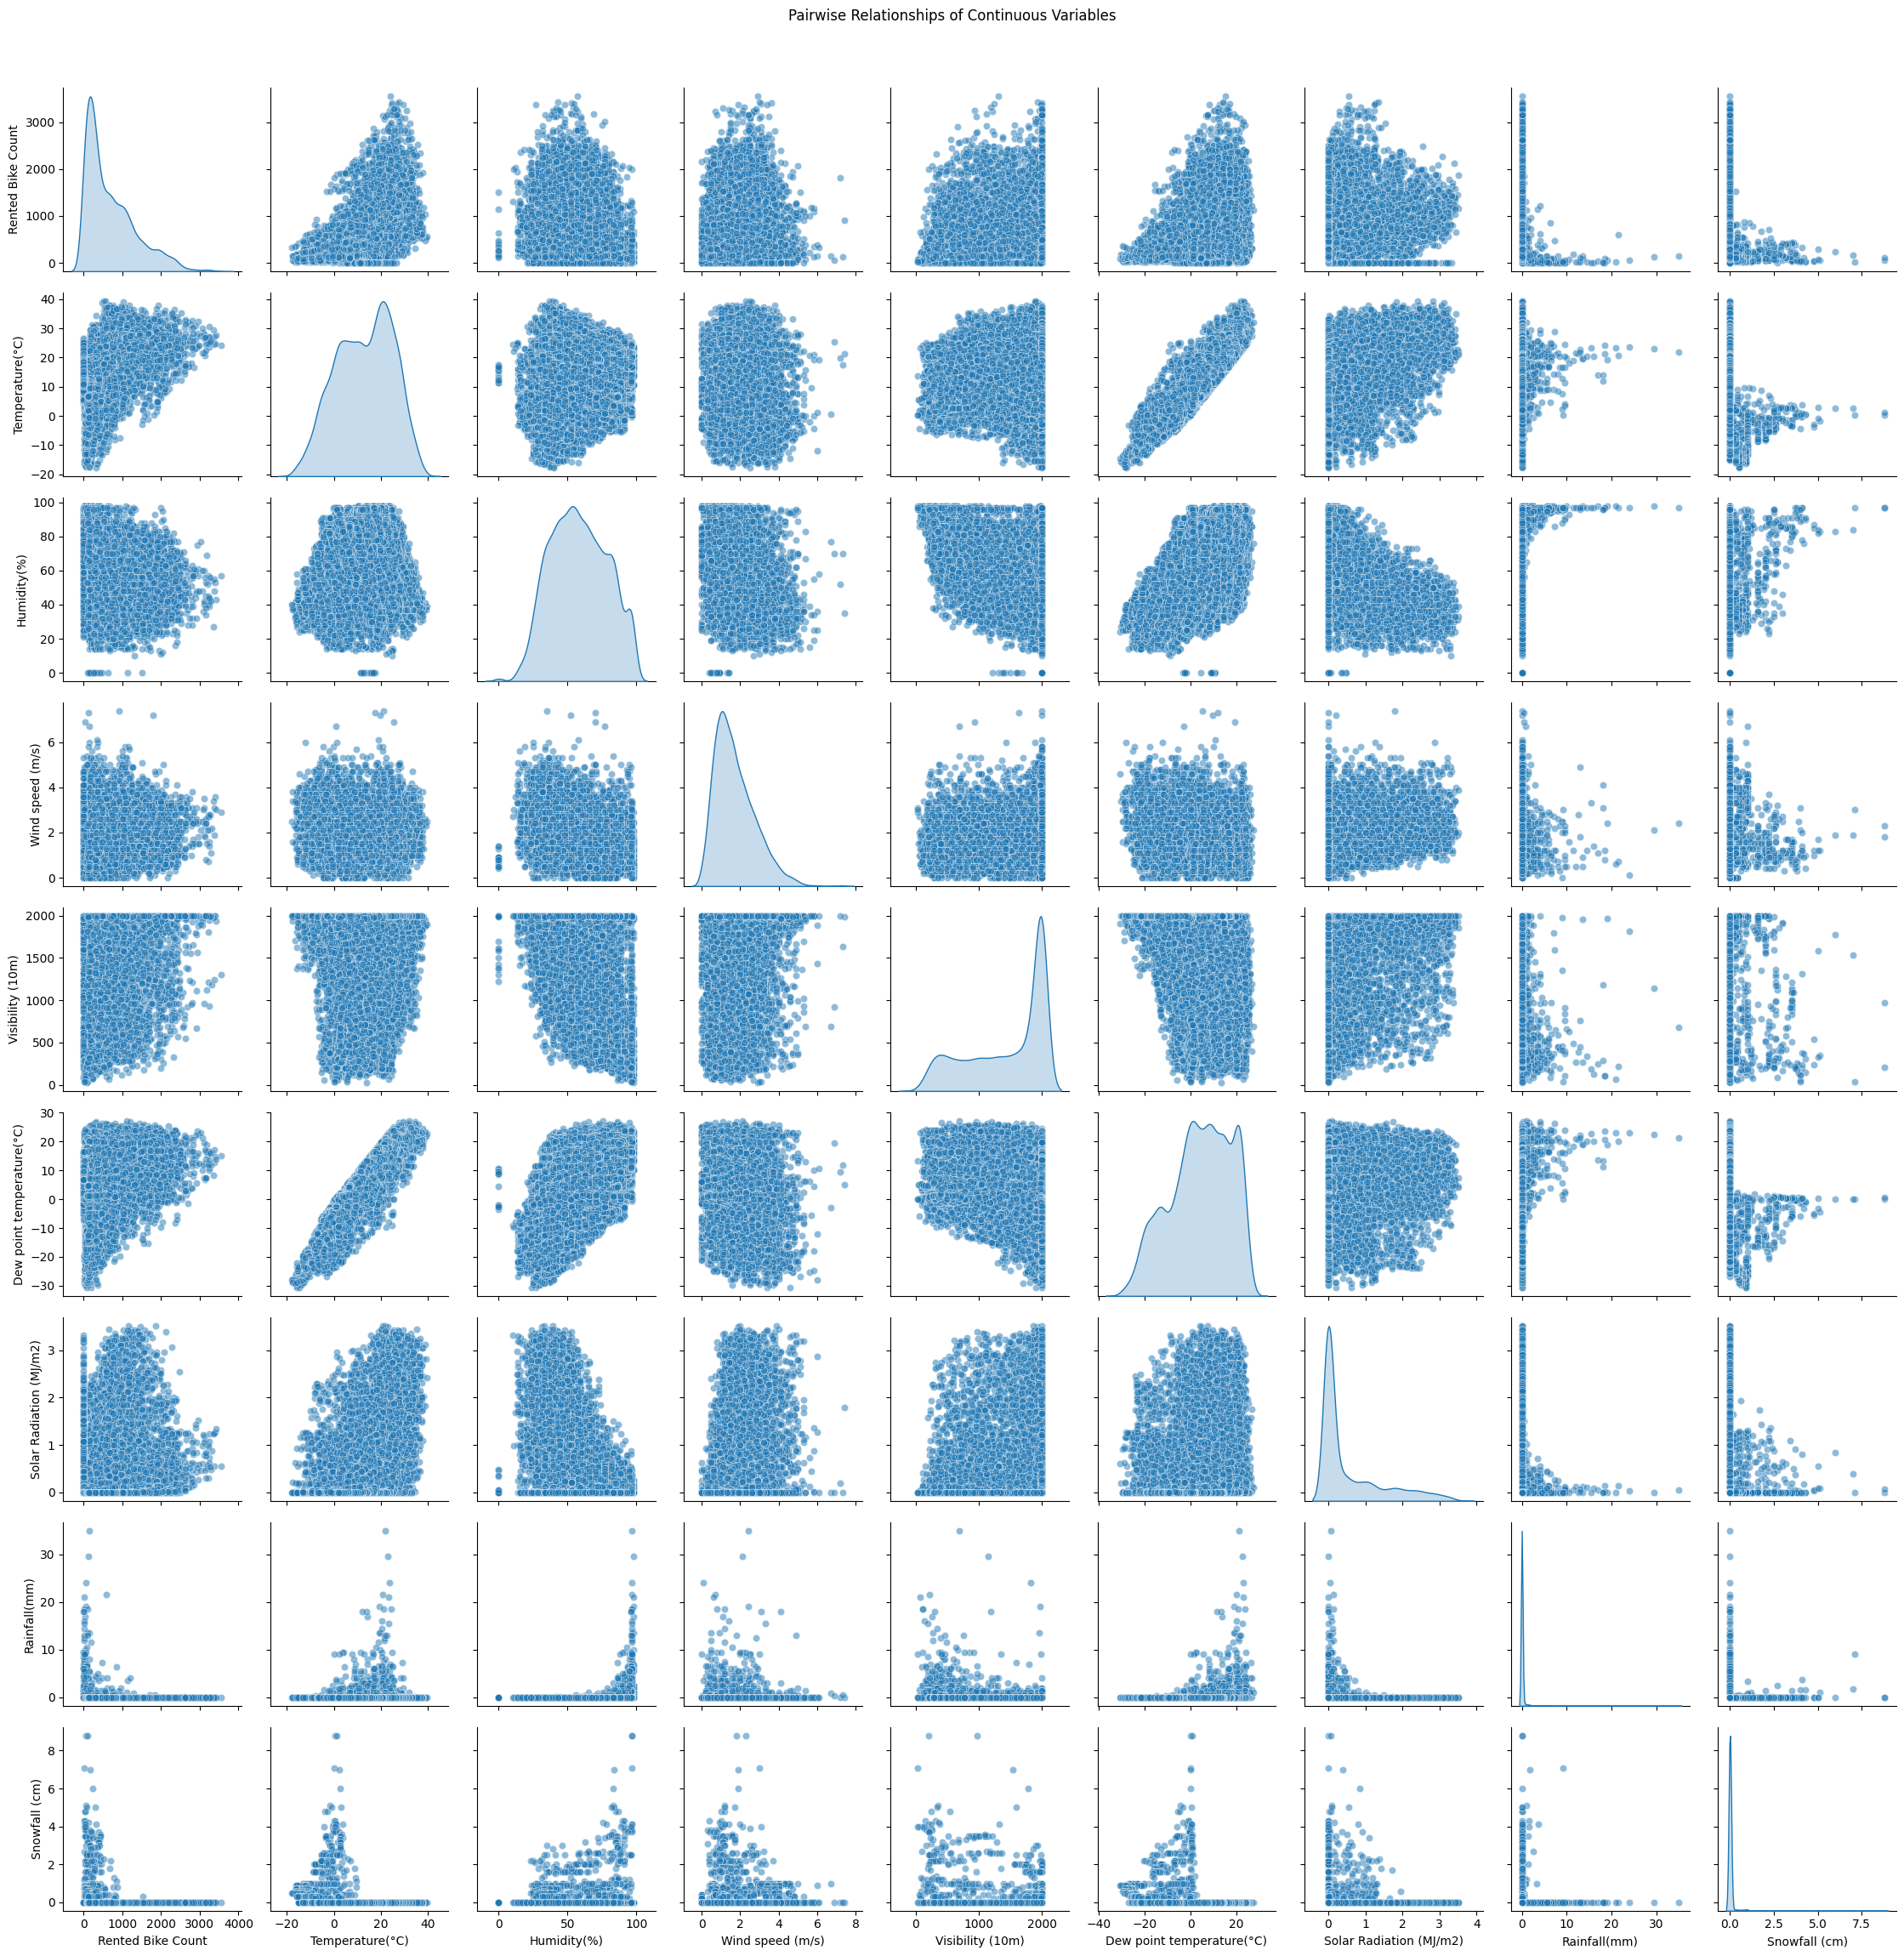

In [11]:
sns.pairplot(df[continuous_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships of Continuous Variables', y=1.02)
plt.tight_layout()
plt.show()

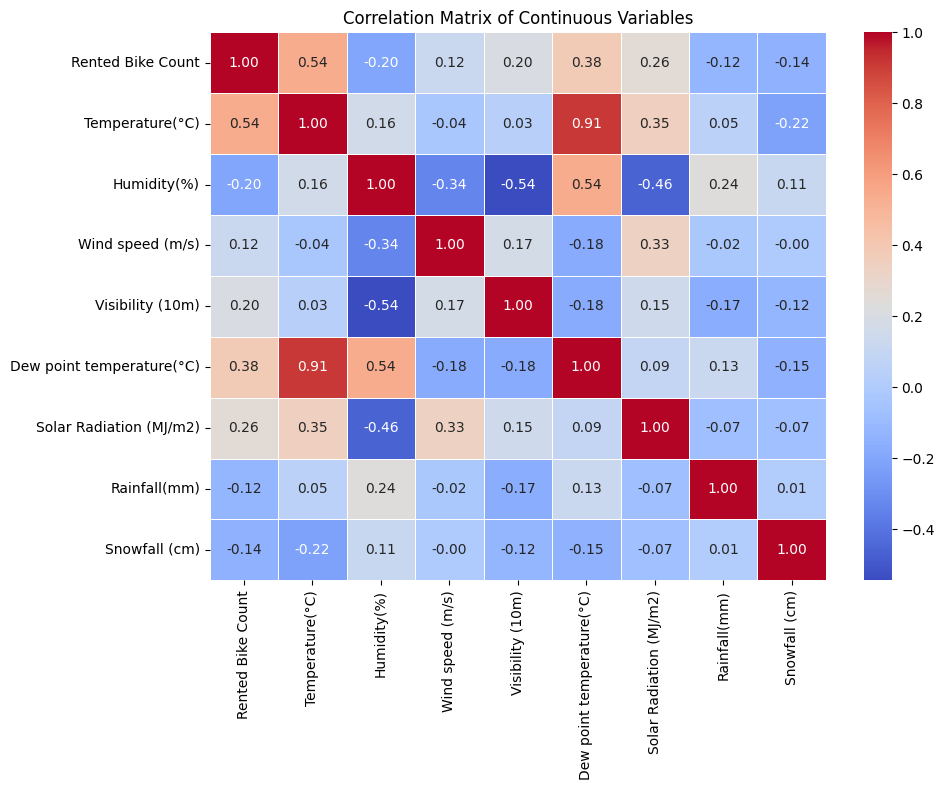

In [12]:
corr_matrix = df[continuous_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()

**Rented Bike Count** shows its strongest positive associations with **Temperature** (0.54) and **Dew point temperature** (0.38), though neither relationship is particularly strong. **Rented Bike Count** also has slight negative associations with **Humidity** (-0.20), **Rainfall** (-0.12), and **Snowfall** (-0.14). **Visibility** and **Humidity** are negatively correlated (-0.54), as well as **Solar Radiation** and **Humidity** (-0.46). **Dew point temperature** and **Humidity** have a relatively strong positive correlation (0.54). **Temperature** and **Dew point temperature** have the strongest correlation, positive (0.91).

We can see that **Rented Bike Count** does not have any strong positive associations with any continuous explanatory variables. 

#### Binary Variables

In [14]:
print(df[binary_cols].describe(include='all'))

           Holiday Functioning Day
count         8760            8760
unique           2               2
top     No Holiday             Yes
freq          8328            8465


## 1 Best Normal Linear Model

### a. Fitting the Model

#### All Explanatory Variables

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [30]:
df_encoded = pd.get_dummies(df.drop(['Date'], axis=1), columns=['Hour', 'Seasons', 'Holiday', 'Functioning Day'], drop_first=True, dtype=int)

X = df_encoded.drop(['Rented Bike Count'], axis=1).iloc[1:]
Y = df_encoded['Rented Bike Count'].iloc[1:]

X = sm.add_constant(X)

In [33]:
model = sm.OLS(Y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     474.6
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:03:30   Log-Likelihood:                -64342.
No. Observations:                8759   AIC:                         1.288e+05
Df Residuals:                    8722   BIC:                         1.290e+05
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

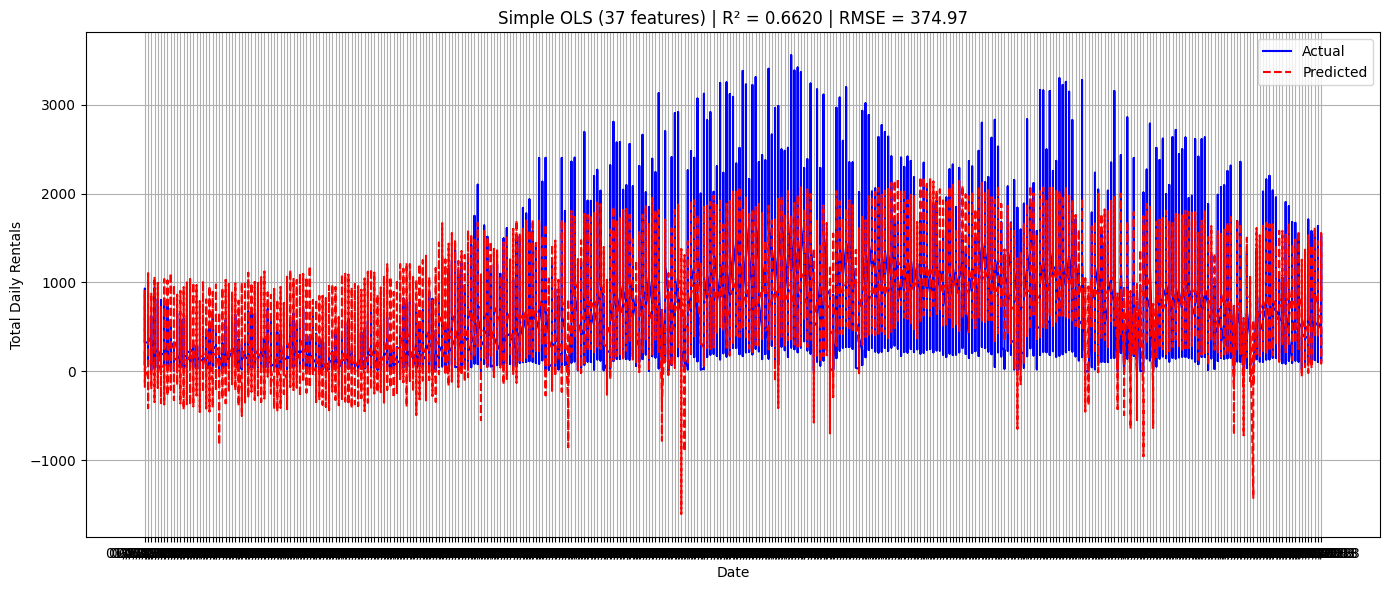

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Predictions
y_pred = model.predict(X)

# 2. Compute metrics
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y, y_pred)
rmse = np.sqrt(mean_squared_error(Y, y_pred))

# 3. Build the plot
plt.figure(figsize=(14,6))

plt.plot(df['Date'].iloc[1:], Y, label='Actual', color='blue')
plt.plot(df['Date'].iloc[1:], y_pred, label='Predicted', color='red', linestyle='--')

plt.title(f"Simple OLS ({X.shape[1]} features) | R² = {r2:.4f} | RMSE = {rmse:.2f}")
plt.xlabel("Date")
plt.ylabel("Total Daily Rentals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### b. Model Interpretation

### c. Model Diagnostics

### d. Model Strengths and Limitations

## 2 Simplest Linear Model

### a. Fitting the Model

### b. Model Interpretation

### c. Model Strengths and Limitations

## 3 Generalized Linear Models (GLMs)

### a. Fitting the Model

### b. Comparison to Previous Models

### c. Model Interpretation

### d. Model Diagnostics